# Project 2 - Sales Analysis - Machine Learning

## Objectives

- Transform the Date column to pandas datetime
- Read data from combined csv file created from ETL processes
- Create machine learning model to predict new hypothesis data
- Show plots to attempt to answer new hypothesis


## Inputs

CSV files used:

Sales_Combined_DataSet_Visualization.csv


## Outputs

Pipeline for use in streamlit 
Plots to show the data and attempt to answer the hypothesis


## Additional Comments

- Developed an experimental ETL library which is in this project (modETL_library.py)   
  Has lots of cool features so will be interesting to see how it works "in the field"

Used various AI tools to help with the visualisation process:
- ChatGPT
- GitHub Copilot

See Documents/What_AI_Used_For.md for more details.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment

In [13]:
%matplotlib inline

#iimport libraries
import os
import streamlit as st
import pandas as pd
import seaborn as sns
import plotly.express as px
import pathlib
import scipy.stats as stats
import matplotlib.pyplot as plt
import nbformat
from matplotlib.ticker import MultipleLocator

#for ML experiments
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve,
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
#from pyexpat import features

#for creating the pipeline file needed by streamlit/Heroku
import joblib

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT


# Hypothesis Being Tested

- What are the predicted sales for store types by month for next year?
- What are the predicted sales for stores in areas of high unemployment by month for next year?

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [14]:
#DataFrame vars for visualisation
dfSalesDataML = None
dfSalesDataML_Work = None
dfTempML = None

#model and image paths
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_TEST_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/linear_regression_hypothesis12_test_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS12_TEST_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/linear_regression_hypothesis12_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_TEST_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/forest_regression_hypothesis12_test_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS12_TEST_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/forest_regression_hypothesis12_test_forecast.png"

CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/linear_regression_hypothesis12_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS12_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/linear_regression_hypothesis12_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/forest_regression_hypothesis12_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS12_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/forest_regression_hypothesis12_forecast.png"

#for copying into streamlit folder
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_TEST_STREAMLIT_PATH =  "streamlit/assets/pipelines/linear_regression_hypothesis12_test_pipeline.pkl"
#CNST_STR_LINEAR_PLOT_HYPOTHESIS12_TEST_STREAMLIT_PATH = "streamlit/linear_regression_hypothesis12_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_TEST_STREAMLIT_PATH = "streamlit/assets/pipelines/forest_regression_hypothesis12_test_pipeline.pkl"
#CNST_STR_FOREST_PLOT_HYPOTHESIS12_TEST_STREAMLIT_PATH = "streamlit/forest_regression_hypothesis12_test_forecast.png"


CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_STREAMLIT_PATH =  "streamlit/assets/pipelines/linear_regression_hypothesis12_pipeline.pkl"
#CNST_STR_LINEAR_PLOT_HYPOTHESIS12_STREAMLIT_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/linear_regression_hypothesis12_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_STREAMLIT_PATH =  "streamlit/assets/pipelines/forest_regression_hypothesis12_pipeline.pkl"
#CNST_STR_FOREST_PLOT_HYPOTHESIS12_STREAMLIT_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/forest_regression_hypothesis12_forecast.png"

#ML vars
dfTrain = pd.DataFrame()
dfTest = pd.DataFrame()
dfXTrain = pd.DataFrame()
dfyTrain = pd.DataFrame()
dfXTest = pd.DataFrame()
dfyTest = pd.DataFrame()
dfPlot = pd.DataFrame()
dfPredictedSales = pd.DataFrame()
dfPrevious = pd.DataFrame()
dfPreviousSales = pd.DataFrame()
dfTestSales = pd.DataFrame()
dfActualSales = pd.DataFrame()
dfFeatures = pd.DataFrame()
dfSales = pd.DataFrame()
dfStores = pd.DataFrame()
dfFeaturesStores = pd.DataFrame()
dfForecast = pd.DataFrame()
dfXForecast = pd.DataFrame()
dfForecastSales = pd.DataFrame()
dfDepts = pd.DataFrame()



lstNumericFeatures = list()
lstCategoricalFeatures = list()
lstFeatures = list()
lstStores = list()
lstSales = list()
lstMarkdown = list()

strTarget = ""

objModel = None
objPipeline = None
objMissingPreviousSales = None
objNumericTransformer = None
objCategoricalTransformer = None
objPreProcessor = None
objyPred = None
objyPred = None
objMissingColumns = None


fltMAE = 0.0
fltRMSE = 0.0
fltR2 = 0.0

intTestYear = 0
intPreviousYear = 0





#other vars
intYear = 0
fig = None
ax = None
intNum = 0
dictDataFrames = dict()
objPipeline = None
objModel = None
X = None
X_Const = None
y = None


## Set Current Directory To Base Project Directory

In [15]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project2-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_Combined_DataSet_Work

In [16]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
#open into DataFrame which can be re-used during visualisations for filtering etc
dfSalesDataML = dictDataFrames["Sales_Combined_DataSet_Visualisation.csv"]

4 csv Files Read Into DataFrames

DataFrames Created:
Sales_Combined_DataSet_Visualisation.csv
Features_DataSet_Visualisation.csv
Sales_DataSet_Visualisation.csv
Stores_DataSet_Visualisation.csv




## Transform Date Column To Datetime Format

In [17]:
#transform Date to datetime
dfSalesDataML["Date"] = pd.to_datetime(dfSalesDataML["Date"], format="%d/%m/%Y")

#check schema
dfSalesDataML.dtypes

#create a working copy of the base DataFrame
dfSalesDataML_Work = dfSalesDataML.copy()

# Initailise Work DataFrame

In [18]:
#setup work DataFrame
dfSalesDataML_Work = dfSalesDataML.copy() 


# Hypothesis 12

What are the predicted sales for store types by month for next year?


# Linear Regression Model - Hypothesis 12 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [19]:
#linear regression test compare last years sales with predicted values for same year

# ============================================================
# 2. CONVERT DATE
# ============================================================

# Walmart dataset dates are in US format in the original dataset
# If your CSV contains dates such as 26/07/2013, use dayfirst=True.
# dfSalesDataML_Work["Date"] = pd.to_datetime(
#     dfSalesDataML["Date"],
#     dayfirst=True,
#     errors="coerce"
# )


# Remove rows where the date could not be converted
dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# Cyclical month features
dfSalesDataML_Work["MonthSin"] = np.sin(2 * np.pi * dfSalesDataML_Work["Month"] / 12)
dfSalesDataML_Work["MonthCos"] = np.cos(2 * np.pi * dfSalesDataML_Work["Month"] / 12)

# Convert boolean to integer
dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. CREATE TRAIN / TEST DATA
# ============================================================

# IMPORTANT:
# 2012 is the test year.
# 2013 is NOT used as the test set.

dfTrain = dfSalesDataML_Work[dfSalesDataML_Work["Year"] < 2012].copy()
dfTest = dfSalesDataML_Work[dfSalesDataML_Work["Year"] == 2012].copy()


print("Training rows:", len(dfTrain))
print("Testing rows:", len(dfTest))

print(
    "Training date range:",
    dfTrain["Date"].min(),
    "to",
    dfTrain["Date"].max()
)

print(
    "Testing date range:",
    dfTest["Date"].min(),
    "to",
    dfTest["Date"].max()
)


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

lstFeatures = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

strTarget = "Weekly_Sales"


dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


# ============================================================
# 6. PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "Store",
    "Dept"
]


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# 7. CREATE LINEAR REGRESSION PIPELINE
# ============================================================

objModel = LinearRegression()


objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# 8. TRAIN
# ============================================================

print("\nTraining Linear Regression...")

objPipeline.fit(dfXtrain, dfyTrain)


# ============================================================
# 9. PREDICT
# ============================================================

objyPred = objPipeline.predict(dfXTest)


# ============================================================
# 10. EVALUATE
# ============================================================

fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)


print("\n==============================")
print("LINEAR REGRESSION RESULTS")
print("==============================")

print(f"MAE:  {fltMAE:,.2f}")
print(f"RMSE: {fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


# ============================================================
# 11. SAVE PIPELINE
# ============================================================

#MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/linear_regression_hypothesis12_test_pipeline.pkl"

#save to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_TEST_PATH
)

#save to streamlit folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_TEST_STREAMLIT_PATH
)


print("\nPipeline saved to:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_TEST_PATH)
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_TEST_STREAMLIT_PATH)








Training rows: 294132
Testing rows: 127438
Training date range: 2010-02-05 00:00:00 to 2011-12-30 00:00:00
Testing date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00

Training Linear Regression...

LINEAR REGRESSION RESULTS
MAE:  7,981.97
RMSE: 12,215.22
R²:   0.6951

Pipeline saved to:
assets/pipelines/linear_regression_hypothesis12_test_pipeline.pkl
streamlit/assets/pipelines/linear_regression_hypothesis12_test_pipeline.pkl


# Linear Regression Plot - Hypothesis 12 - Test

Visualise the model results

Test year: 2012
Previous year: 2011
Test rows: 127438
Previous year rows: 153453

Plot data:
         Date  WeekOfYear  Actual_Sales  Predicted_Sales  Previous_Year_Sales
0  2012-01-06           1   44955421.95     3.983875e+07          42775787.77
1  2012-01-13           2   42023078.48     3.969132e+07          40673678.04
2  2012-01-20           3   42080996.56     3.959686e+07          40654648.03
3  2012-01-27           4   39834974.67     3.946884e+07          39599852.99
4  2012-02-03           5   46085608.09     4.646054e+07          46153111.12
5  2012-02-10           6   50009407.92     4.716709e+07          47336192.79
6  2012-02-17           7   50197056.96     4.624758e+07          48716164.12
7  2012-02-24           8   45771506.57     4.594896e+07          44125859.84
8  2012-03-02           9   46861034.97     4.751260e+07          46980603.74
9  2012-03-09          10   47480454.11     4.750274e+07          44627319.40
10 2012-03-16          11   46901504.94     4.730

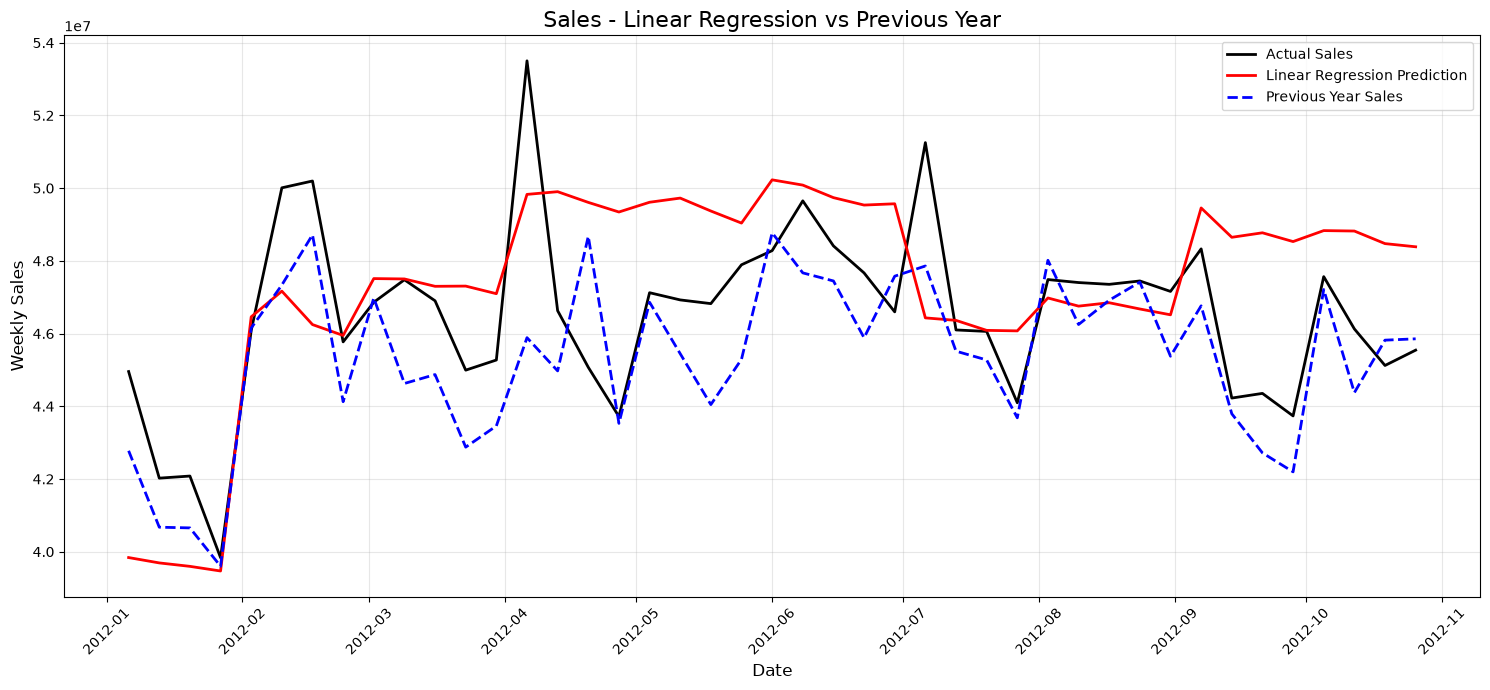

In [20]:

# ============================================================
# 2. CONVERT DATE
# ============================================================

# dfSalesDataML_Work["Date"] = pd.to_datetime(
#     dfSalesDataML["Date"],
#     dayfirst=True,
#     errors="coerce"
# )

dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work    ["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. LOAD LINEAR REGRESSION PIPELINE
# ============================================================

#MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/linear_regression_hypothesis12_test_pipeline.pkl"

objPipeline = joblib.load(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_TEST_PATH)


# ============================================================
# 5. SELECT TEST AND PREVIOUS YEAR
# ============================================================

intYear= 2012
intPreviousYear = intYear - 1

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == intYear
].copy()

dfPrevious = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == intPreviousYear
].copy()


print("Test year:", intYear)
print("Previous year:", intPreviousYear)

print(
    "Test rows:",
    len(dfTest)
)

print(
    "Previous year rows:",
    len(dfPrevious)
)


# ============================================================
# 6. FEATURES
# ============================================================

lstFeatures = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]


# ============================================================
# 7. GENERATE MODEL PREDICTIONS
# ============================================================

dfXTest = dfTest[lstFeatures]

dfTest["Predicted_Sales"] = objPipeline.predict(
    dfXTest
)


# ============================================================
# 8. ACTUAL 2012 SALES BY WEEK
# ============================================================

dfActualSales = (
    dfTest
    .groupby(
        ["Date", "WeekOfYear"]
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

dfActualSales = dfActualSales.rename(
    columns={
        "Weekly_Sales": "Actual_Sales"
    }
)


# ============================================================
# 9. PREDICTED 2012 SALES BY WEEK
# ============================================================

dfPredictedSales = (
    dfTest
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 10. PREVIOUS YEAR SALES BY WEEK
# ============================================================

dfPreviousSales = (
    dfPrevious
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

dfPreviousSales = dfPreviousSales.rename(
    columns={
        "Weekly_Sales": "Previous_Year_Sales"
    }
)


# ============================================================
# 11. MERGE ACTUAL AND PREDICTED
# ============================================================

plot_df = dfActualSales.merge(
    dfPredictedSales,
    on=["Date", "WeekOfYear"],
    how="left"
)


# ============================================================
# 12. MERGE PREVIOUS YEAR
# ============================================================

plot_df = plot_df.merge(
    dfPreviousSales,
    on="WeekOfYear",
    how="left"
)


# Sort chronologically

plot_df = plot_df.sort_values(
    "Date"
)


# ============================================================
# 13. CHECK THE DATA
# ============================================================

print("\nPlot data:")

print(
    plot_df[
        [
            "Date",
            "WeekOfYear",
            "Actual_Sales",
            "Predicted_Sales",
            "Previous_Year_Sales"
        ]
    ].head(20)
)


# Check for missing previous year values

missing_previous = plot_df[
    "Previous_Year_Sales"
].isna().sum()

print(
    "\nMissing previous-year values:",
    missing_previous
)


# ============================================================
# 14. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Actual sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Actual_Sales"],
    label="Actual Sales",
    color="black",
    linewidth=2
)


# ------------------------------------------------------------
# Linear Regression predictions
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    label="Linear Regression Prediction",
    color="red",
    linewidth=2
)


# ------------------------------------------------------------
# Previous year sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Previous_Year_Sales"],
    label="Previous Year Sales",
    color="blue",
    linestyle="--",
    linewidth=2
)


# ============================================================
# 15. FORMAT GRAPH
# ============================================================

plt.title(
    "Sales - Linear Regression vs Previous Year",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Weekly Sales",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 16. SAVE GRAPH
# ============================================================

plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS12_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 17. SHOW GRAPH
# ============================================================

plt.show()

# Observations - Linear Regression Test - Hypothesis 12

dfd

# Random Forest - Hypothesis 12 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [21]:
#random forestplot test compare last years sales with predicted values for same year



# ============================================================
# 2. CONVERT DATE
# ============================================================

# Use dayfirst=True if your dates are written:
#
# 26/07/2013
#
# rather than:
#
# 07/26/2013

# dfSalesDataML_Work["Date"] = pd.to_datetime(
#     dfSalesDataML_Work["Date"],
#     dayfirst=True,
#     errors="coerce"
# )

dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work            ["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# Cyclical month features

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. CREATE TRAIN / TEST DATA
# ============================================================

# Training:
# All years before 2012
#
# Testing:
# 2012 only
#
# 2013 is deliberately NOT used for testing.

dfTrain = dfSalesDataML_Work[dfSalesDataML_Work["Year"] < 2012].copy()

dfTest = dfSalesDataML_Work[dfSalesDataML_Work["Year"] == 2012].copy()


print("Training rows:", len(dfTrain))
print("Testing rows:", len(dfTest))

print(
    "Training date range:",
    dfTrain["Date"].min(),
    "to",
    dfTrain["Date"].max()
)

print(
    "Testing date range:",
    dfTest["Date"].min(),
    "to",
    dfTest["Date"].max()
)


# ============================================================
# 5. FEATURES / TARGET
# ============================================================

lstFeatures = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

strTarget = "Weekly_Sales"


dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


# ============================================================
# 6. PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "Store",
    "Dept"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


objPreProcessor= ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# 7. RANDOM FOREST
# ============================================================

objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)


# ============================================================
# 8. CREATE PIPELINE
# ============================================================

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# 9. TRAIN
# ============================================================

print("\nTraining Random Forest...")

objPipeline.fit(
    dfXTrain,
    dfyTrain
)


# ============================================================
# 10. PREDICT
# ============================================================

objyPred = objPipeline.predict(dfXTest)


# ============================================================
# 11. EVALUATE
# ============================================================

fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print(f"MAE:  {fltMAE:,.2f}")
print(f"RMSE: {fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


# ============================================================
# 12. SAVE PIPELINE
# ============================================================

#MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/random_forest_hypothesis12_test_pipeline.pkl"

joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_TEST_PATH
)

#save to streamlit folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_TEST_STREAMLIT_PATH
)

print("\nPipeline saved to:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_TEST_PATH)
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_TEST_STREAMLIT_PATH)

Training rows: 294132
Testing rows: 127438
Training date range: 2010-02-05 00:00:00 to 2011-12-30 00:00:00
Testing date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00

Training Random Forest...

RANDOM FOREST RESULTS
MAE:  7,424.41
RMSE: 10,070.20
R²:   0.7928

Pipeline saved to:
assets/pipelines/forest_regression_hypothesis12_test_pipeline.pkl
streamlit/assets/pipelines/forest_regression_hypothesis12_test_pipeline.pkl


# Random Forest - Plot - Hypothesis 12 - Test

Visualise the model results


Test year: 2012
Previous year: 2011
Test rows: 127438
Previous year rows: 153453

Plot data:
         Date  WeekOfYear  Actual_Sales  Predicted_Sales  Previous_Year_Sales
0  2012-01-06           1   44955421.95     4.692281e+07          42775787.77
1  2012-01-13           2   42023078.48     4.649498e+07          40673678.04
2  2012-01-20           3   42080996.56     4.628272e+07          40654648.03
3  2012-01-27           4   39834974.67     4.588932e+07          39599852.99
4  2012-02-03           5   46085608.09     4.813346e+07          46153111.12
5  2012-02-10           6   50009407.92     4.831029e+07          47336192.79
6  2012-02-17           7   50197056.96     4.804668e+07          48716164.12
7  2012-02-24           8   45771506.57     4.715483e+07          44125859.84
8  2012-03-02           9   46861034.97     4.778369e+07          46980603.74
9  2012-03-09          10   47480454.11     4.763076e+07          44627319.40
10 2012-03-16          11   46901504.94     4.661

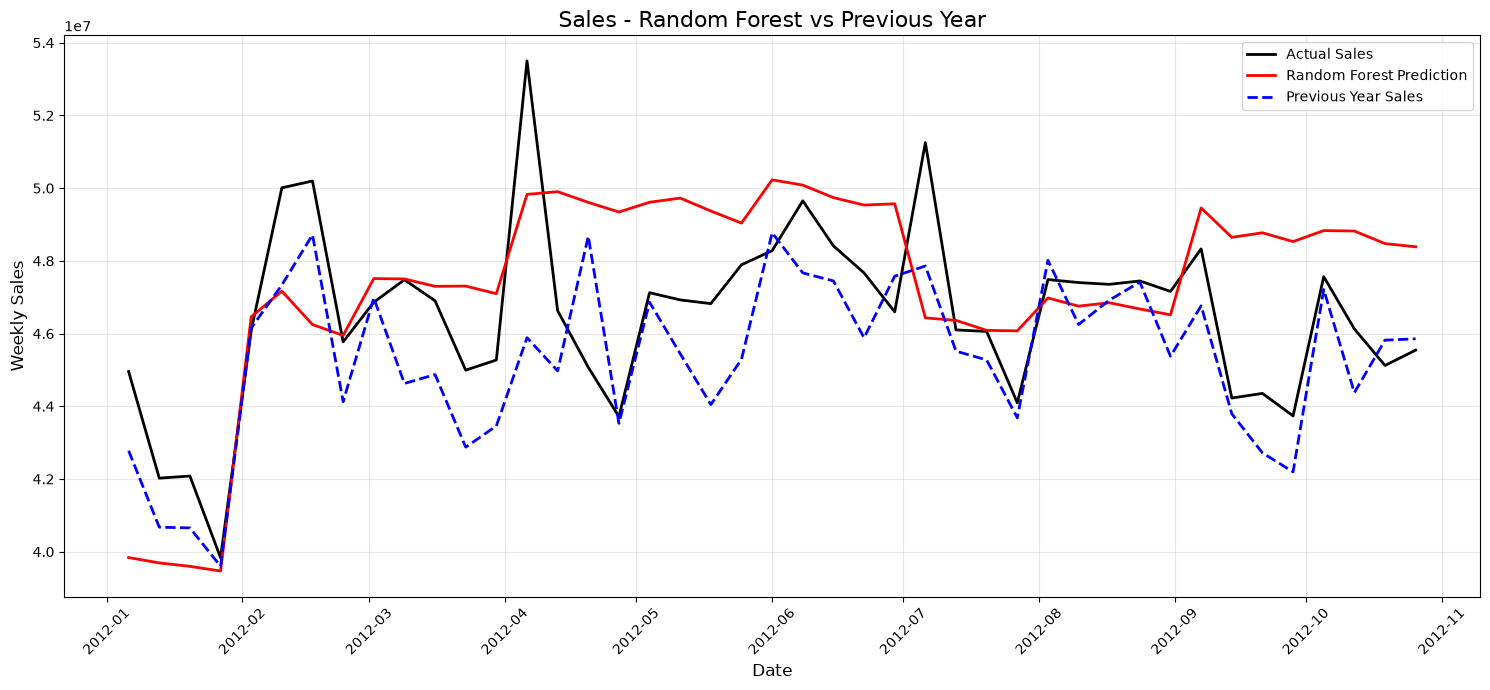

In [26]:
#random forest plot test compare last years sales with predicted values for same year


# ============================================================
# 2. CONVERT DATE
# ============================================================

# dfSalesDataML_Work["Date"] = pd.to_datetime(
#     dfSalesDataML_Work["Date"],
#     dayfirst=True,
#     errors="coerce"
# )

dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# Cyclical month features

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. LOAD RANDOM FOREST PIPELINE
# ============================================================

#MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/random_forest_hypothesis12_test_pipeline.pkl"

objPipeline = joblib.load(CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_TEST_PATH)


# ============================================================
# 5. SELECT TEST AND PREVIOUS YEAR
# ============================================================

intYear= 2012
intPreviousYear = intYear - 1
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == intYear   
].copy()

dfPrevious = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == intPreviousYear
].copy()


print("Test year:", intYear)
print("Previous year:", intPreviousYear)

print(
    "Test rows:",
    len(dfTest)
)

print(
    "Previous year rows:",
    len(dfPrevious)
)


# ============================================================
# 6. FEATURES
# ============================================================

lstFeatures = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]


# ============================================================
# 7. GENERATE RANDOM FOREST PREDICTIONS
# ============================================================

X_test = dfTest[lstFeatures]

dfTest["Predicted_Sales"] = objPipeline.predict(
    X_test
)


# ============================================================
# 8. ACTUAL 2012 SALES BY WEEK
# ============================================================

dfActualSales = (
    dfTest
    .groupby(
        ["Date", "WeekOfYear"]
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

dfActualSales = dfActualSales.rename(
    columns={
        "Weekly_Sales": "Actual_Sales"
    }
)


# ============================================================
# 9. PREDICTED 2012 SALES BY WEEK
# ============================================================

dfPredictedSales = (
    dfTest
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 10. PREVIOUS YEAR SALES BY WEEK
# ============================================================

dfPreviousSales = (
    dfPrevious
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

dfPreviousSales = dfPreviousSales.rename(
    columns={
        "Weekly_Sales": "Previous_Year_Sales"
    }
)


# ============================================================
# 11. MERGE ACTUAL AND PREDICTED SALES
# ============================================================

dfPlot = dfActualSales.merge(
    dfPredictedSales,
    on=["Date", "WeekOfYear"],
    how="left"
)


# ============================================================
# 12. MERGE PREVIOUS YEAR SALES
# ============================================================
    
dfPlot = dfPlot.merge(
    dfPreviousSales,
    on="WeekOfYear",
    how="left"
)


# Sort by date

dfPlot = dfPlot.sort_values(
    "Date"
)


# ============================================================
# 13. CHECK DATA
# ============================================================

print("\nPlot data:")

print(
    dfPlot[
        [
            "Date",
            "WeekOfYear",
            "Actual_Sales",
            "Predicted_Sales",
            "Previous_Year_Sales"
        ]
    ].head(20)
)


# Check missing previous-year values

dfMissingPrevious = (
    dfPlot["Previous_Year_Sales"]
    .isna()
    .sum()
)

print(
    "\nMissing previous-year values:",
    dfMissingPrevious
)


# ============================================================
# 14. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Actual sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Actual_Sales"],
    label="Actual Sales",
    color="black",
    linewidth=2
)


# ------------------------------------------------------------
# Random Forest predictions
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    label="Random Forest Prediction",
    color="red",
    linewidth=2
)


# ------------------------------------------------------------
# Previous year sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Previous_Year_Sales"],
    label="Previous Year Sales",
    color="blue",
    linestyle="--",
    linewidth=2
)


# ============================================================
# 15. FORMAT GRAPH
# ============================================================

plt.title(
    "Sales - Random Forest vs Previous Year",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Weekly Sales",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 16. SAVE GRAPH
# ============================================================

plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS12_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 17. SHOW GRAPH
# ============================================================

plt.show()

# Observations Random Forest Model - Hypothesis 12 - Tests

sds


# Linear Regression Model - Hypothesis 12 - Plot

Predict 2013 Sales



Features date range:
2010-01-10 00:00:00 to 2013-12-07 00:00:00

Sales date range:
2010-01-10 00:00:00 to 2012-12-10 00:00:00

Features + Stores: (3285, 14)

Training dataset: (168156, 17)

Forecast dataset: (42874, 15)

Forecast date range:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

Training Linear Regression...
Training complete.

Pipeline saved:
assets/pipelines/linear_regression_hypothesis12_pipeline.pkl
streamlit/assets/pipelines/linear_regression_hypothesis12_pipeline.pkl

Generating 2013 predictions...

2013 prediction rows: 42874

2013 prediction period:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

Plot saved:
reports/images/linear_regression_hypothesis12_forecast.png


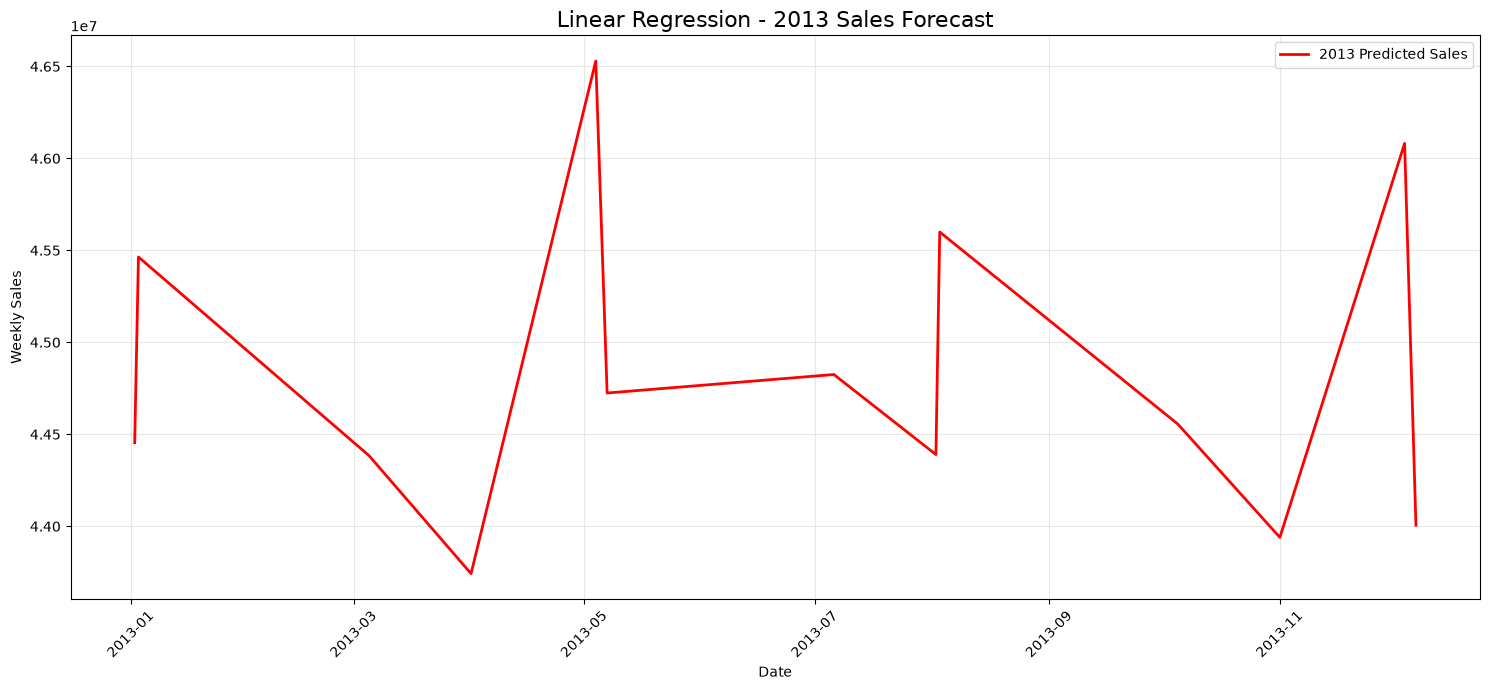

In [22]:
# linear regression plot predict next years sales 




# ============================================================
# 1. FILE PATHS
# ============================================================

# FEATURES_PATH = dictDataFrames["Features_DataSet_Visualisation.csv"]
# SALES_PATH = dictDataFrames["Sales_DataSet.csv"]
# STORES_PATH = dictDataFrames["Stores_DataSet.csv"]


dfFeatures = dictDataFrames["Features_DataSet_Visualisation.csv"]
dfSales = dictDataFrames["Sales_DataSet_Visualisation.csv"]
dfStores = dictDataFrames["Stores_DataSet_Visualisation.csv"]

#MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/linear_regression_hypothesis12_pipeline.pkl"
#PLOT_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/linear_regression_hypothesis12_forecast.png"


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

# dfFeatures.columns = (
#     dfFeatures.columns
#     .str.strip()
# )

# dfSales.columns = (
#     dfSales.columns
#     .str.strip()
# )

# dfStores.columns = (
#     dfStores.columns
#     .str.strip()
# )


# ============================================================
# 4. CONVERT DATES
# ============================================================

dfFeatures["Date"] = pd.to_datetime(
    dfFeatures["Date"],
    errors="coerce"
)

dfSales["Date"] = pd.to_datetime(
    dfSales["Date"],
    errors="coerce"
)


# Remove invalid dates

dfFeatures = dfFeatures.dropna(
    subset=["Date"]
)

dfSales = dfSales.dropna(
    subset=["Date"]
)


print("\nFeatures date range:")

print(
    dfFeatures["Date"].min(),
    "to",
    dfFeatures["Date"].max()
)


print("\nSales date range:")

print(
    dfSales["Date"].min(),
    "to",
    dfSales["Date"].max()
)


# ============================================================
# 5. MERGE FEATURES WITH STORES
# ============================================================

dfFeaturesStores = dfFeatures.merge(
    dfStores,
    on="Store",
    how="left"
)


print(
    "\nFeatures + Stores:",
    dfFeaturesStores.shape
)


# ============================================================
# 6. CREATE TRAINING DATA
# ============================================================

# Sales contains the target Weekly_Sales.
#
# Merge sales with Features + Stores.
#
# Sales are at Store + Dept + Date level.
# Features are at Store + Date level.

dfTrain = dfSales.merge(
    dfFeaturesStores,
    on=[
        "Store",
        "Date",
        "IsHoliday"
    ],
    how="left"
)


print(
    "\nTraining dataset:",
    dfTrain.shape
)


# ============================================================
# 7. CREATE FORECAST DATA
# ============================================================

# The features dataset contains dates beyond
# the sales dataset.
#
# We use these dates to predict future sales.

dfForecast = dfFeaturesStores[
    dfFeaturesStores["Date"] >
    dfSales["Date"].max()
].copy()


# We need predictions for every Store/Department
# combination that existed in the sales data.
dfDepts = dfSales[
    ["Store", "Dept"]
].drop_duplicates()


dfForecast = dfForecast.merge(
    dfDepts,
    on="Store",
    how="inner"
)


print(
    "\nForecast dataset:",
    dfForecast.shape
)


print(
    "\nForecast date range:"
)

print(
    dfForecast["Date"].min(),
    "to",
    dfForecast["Date"].max()
)


# ============================================================
# 8. FEATURE ENGINEERING FUNCTION
# ============================================================

def create_features(df):

    df = df.copy()

    # Date features

    df["Year"] = (
        df["Date"].dt.year
    )

    df["Month"] = (
        df["Date"].dt.month
    )

    df["Day"] = (
        df["Date"].dt.day
    )

    df["DayOfWeek"] = (
        df["Date"].dt.dayofweek
    )

    df["WeekOfYear"] = (
        df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["Quarter"] = (
        df["Date"].dt.quarter
    )

    # Cyclical features

    df["MonthSin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )

    df["MonthCos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )

    df["WeekSin"] = np.sin(
        2 * np.pi * df["WeekOfYear"] / 52
    )

    df["WeekCos"] = np.cos(
        2 * np.pi * df["WeekOfYear"] / 52
    )

    # Holiday

    df["IsHoliday"] = (
        df["IsHoliday"]
        .astype(int)
    )

    return df


dfTrain= create_features(
    dfTrain
)

dfForecast = create_features(
    dfForecast
)


# ============================================================
# 9. HANDLE MARKDOWN COLUMNS
# ============================================================

lstMarkdown = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


for column in lstMarkdown:

    if column in dfTrain.columns:

        dfTrain[column] = (
            dfTrain[column]
            .fillna(0)
        )

    if column in dfForecast.columns:

        dfForecast[column] = (
            dfForecast[column]
            .fillna(0)
        )


# ============================================================
# 10. FEATURES USED BY MODEL
# ============================================================
lstFeatures = [

    # Store information
    "Store",
    "Dept",
    "Store_Type",
    "Size",

    # Date information
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    # Cyclical features
    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    # Holiday
    "IsHoliday",

    # Walmart economic features
    "Temperature",
    "Unemployment",

    # Markdown
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


strTarget = "Weekly_Sales"


# ============================================================
# 11. CHECK COLUMNS
# ============================================================

objMissingColumns = [
    column
    for column in lstFeatures
    if column not in dfTrain.columns
]


if objMissingColumns:

    raise ValueError(
        f"Missing columns: {objMissingColumns}"
    )


# ============================================================
# 12. X AND Y
# ============================================================

dfXTrain = dfTrain[
    lstFeatures
]

dfyTrain = dfTrain[
    strTarget
]

dfXForecast = dfForecast[
    lstFeatures
]


# ============================================================
# 13. PREPROCESSING
# ============================================================

lstNumericFeatures = [

    "Size",

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    "IsHoliday",

    "Temperature",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


lstCategoricalFeatures = [
    "Store",
    "Dept",
    "Store_Type"
]


objNumericTransformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),

        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# 14. LINEAR REGRESSION
# ============================================================

objModel = LinearRegression()


objPipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            objPreProcessor
        ),

        (
            "model",
            objModel
        )
    ]
)


# ============================================================
# 15. TRAIN
# ============================================================

print(
    "\nTraining Linear Regression..."
)

objPipeline.fit(
    dfXTrain,
    dfyTrain
)

print(
    "Training complete."
)


# ============================================================
# 16. SAVE PIPELINE
# ============================================================

joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_PATH
)

#save to sreamlit folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_STREAMLIT_PATH
)

print(
    "\nPipeline saved:"
)

print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_PATH)
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_STREAMLIT_PATH)


# ============================================================
# 17. PREDICT 2013
# ============================================================

print(
    "\nGenerating 2013 predictions..."
)
dfForecast["Predicted_Sales"] = (
    objPipeline.predict(
        dfXForecast
    )
)


# ============================================================
# 18. SELECT 2013
# ============================================================

dfTest = dfForecast[
    dfForecast["Date"].dt.year == 2013
].copy()


print(
    "\n2013 prediction rows:",
    len(dfTest)
)


print(
    "\n2013 prediction period:"
)

print(
    dfTest["Date"].min(),
    "to",
    dfTest["Date"].max()
)


# ============================================================
# 19. AGGREGATE 2013 PREDICTIONS
# ============================================================

dfForecast = (
    dfTest
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 20. GET 2012 ACTUAL SALES
# ============================================================

dfActualSales = dfTrain[
    dfTrain["Year"] == 2012
].copy()


dfPrevious = (
    dfActualSales
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)


dfPrevious = dfPrevious.rename(
    columns={
        "Weekly_Sales":
        "Previous_Year_Sales"
    }
)


# ============================================================
# 21. MERGE FOR PLOT
# ============================================================
dfPlot= dfForecast.merge(
    dfPrevious,
    on="WeekOfYear",
    how="left"
)


dfPlot = dfPlot.sort_values(
    "Date"
)


# ============================================================
# 22. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


plt.plot(
    dfPlot["Date"],
    dfPlot["Predicted_Sales"],
    color="red",
    linewidth=2,
    label="2013 Predicted Sales"
)


plt.title(
    "Linear Regression - 2013 Sales Forecast",
    fontsize=16
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Weekly Sales"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 23. SAVE PLOT
# ============================================================

plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS12_PATH,
    dpi=300,
    bbox_inches="tight"
)


print(
    "\nPlot saved:"
)

print(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS12_PATH
)


plt.show()

# Observations - Linear Regression - Hypothesis 12

hjhg

# Random Forest Model - Hypothesis 12 - Plot

Loading datasets...
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    421570 non-null  int64         
 1   Store         421570 non-null  int64         
 2   Dept          421570 non-null  int64         
 3   Date          168156 non-null  datetime64[us]
 4   Weekly_Sales  421570 non-null  float64       
 5   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(3)
memory usage: 16.5 MB
None

Sales: 2010-01-10 00:00:00 to 2012-12-10 00:00:00
Features: 2010-01-10 00:00:00 to 2013-12-07 00:00:00

Training rows: 168156
Forecast rows: 42874

Training Random Forest...
Training complete.

Pipeline saved:
assets/pipelines/forest_regression_hypothesis12_pipeline.pkl
streamlit/assets/pipelines/forest_regression_hypothesis12_pipeline.pkl

Generating predictions...

2013 rows: 42874
2

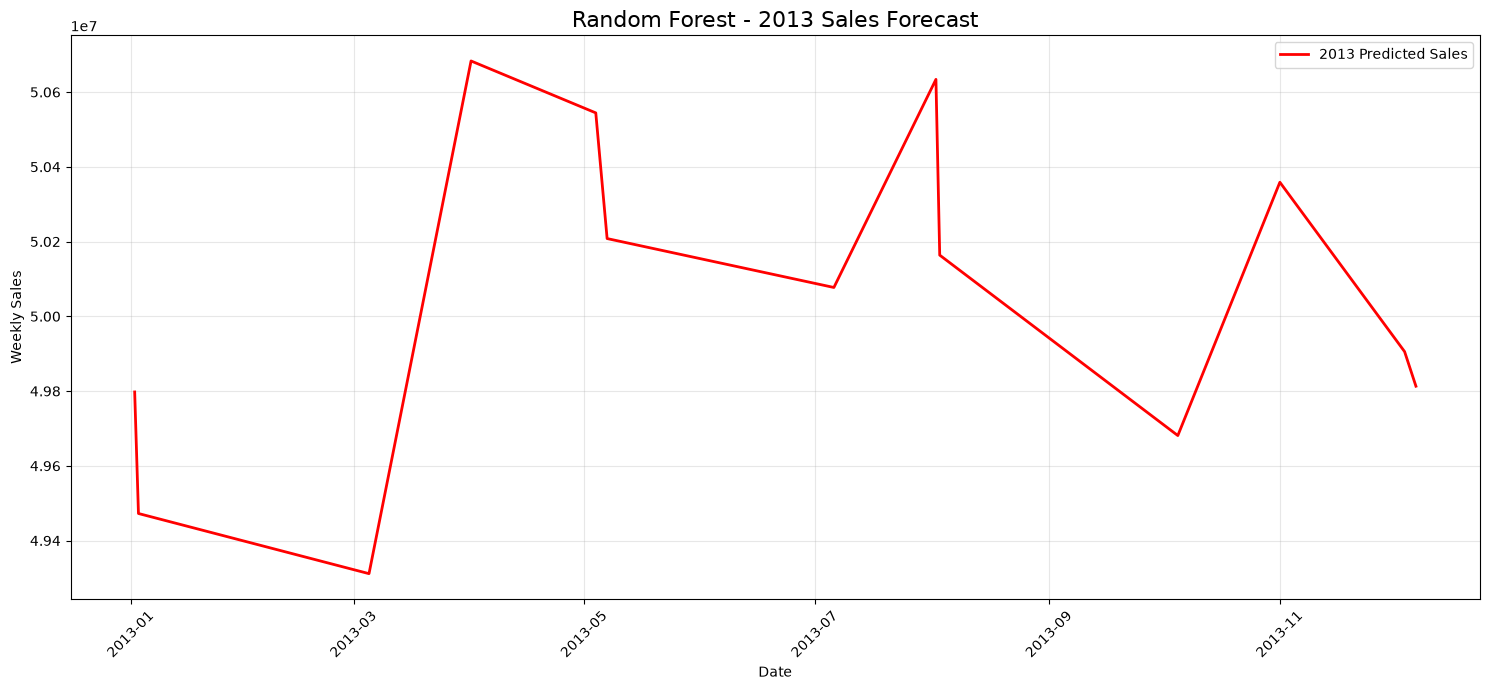

In [27]:
#random forest predict next years sales




# ============================================================
# FILES
# ============================================================
dfFeatures = dictDataFrames["Features_DataSet_Visualisation.csv"]
dfSales = dictDataFrames["Sales_DataSet_Visualisation.csv"]
dfStores = dictDataFrames["Stores_DataSet_Visualisation.csv"]

# MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/random_forest_hypothesis12_pipeline.pkl"
# PLOT_PATH = modGlobal.CNST_STR_REPORTIMAGESPATH + "/random_forest_hypothesis12_forecast.png"


# ============================================================
# LOAD
# ============================================================

print("Loading datasets...")

print(dfSales.info())

# lstFeatures= (
#     dfFeatures.columns.str.strip()
# )

# dfSales = (
#     dfSales.columns.str.strip()
# )

# dfStores.columns = (
#     dfStores.columns.str.strip()
# )


# ============================================================
# DATES
# ============================================================

dfFeatures["Date"] = pd.to_datetime(
    dfFeatures["Date"],
    errors="coerce"
)

dfSales["Date"] = pd.to_datetime(
    dfSales["Date"],
    errors="coerce"
)


dfFeatures = dfFeatures.dropna(
    subset=["Date"]
)

dfSales = dfSales.dropna(
    subset=["Date"]
)


print(
    "\nSales:",
    dfSales["Date"].min(),
    "to",
    dfSales["Date"].max()
)

print(
    "Features:",
    dfFeatures["Date"].min(),
    "to",
    dfFeatures["Date"].max()
)


# ============================================================
# FEATURES + STORES
# ============================================================

dfFeaturesStores = dfFeatures.merge(
    dfStores,
    on="Store",
    how="left"
)


# ============================================================
# TRAINING DATA
# ============================================================

training_df = dfSales.merge(
    dfFeaturesStores,
    on=[
        "Store",
        "Date",
        "IsHoliday"
    ],
    how="left"
)


# ============================================================
# FORECAST DATA
# ============================================================

dfForecast = dfFeaturesStores[
    dfFeaturesStores["Date"] >
    dfSales["Date"].max()
].copy()


store_depts = dfSales[
    ["Store", "Dept"]
].drop_duplicates()


dfForecast = dfForecast.merge(
    store_depts,
    on="Store",
    how="inner"
)


print(
    "\nTraining rows:",
    len(training_df)
)

print(
    "Forecast rows:",
    len(dfForecast)
)


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(df):

    df = df.copy()

    df["Year"] = df["Date"].dt.year

    df["Month"] = df["Date"].dt.month

    df["Day"] = df["Date"].dt.day

    df["DayOfWeek"] = (
        df["Date"].dt.dayofweek
    )

    df["WeekOfYear"] = (
        df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["Quarter"] = (
        df["Date"].dt.quarter
    )

    df["MonthSin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )

    df["MonthCos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )

    df["WeekSin"] = np.sin(
        2 * np.pi *
        df["WeekOfYear"] / 52
    )

    df["WeekCos"] = np.cos(
        2 * np.pi *
        df["WeekOfYear"] / 52
    )

    df["IsHoliday"] = (
        df["IsHoliday"]
        .astype(int)
    )

    return df


dfTrain = create_features(
    dfTrain
)

dfForecast = create_features(
    dfForecast
)


# ============================================================
# MARKDOWNS
# ============================================================

markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


for column in markdown_columns:

    if column in training_df.columns:

        training_df[column] = (
            training_df[column]
            .fillna(0)
        )

    if column in dfForecast.columns:

        dfForecast[column] = (
            dfForecast[column]
            .fillna(0)
        )


# ============================================================
# FEATURES
# ============================================================

lstFeatures = [

    "Store",
    "Dept",
    "Store_Type",
    "Size",

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    "IsHoliday",

    "Temperature",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


dfXtrain = dfTrain[
    lstFeatures
]

dfyTrain = dfTrain[
    "Weekly_Sales"
]

dfXForecast = dfForecast[
    lstFeatures
]


# ============================================================
# PREPROCESSING
# ============================================================

lstNumericFeatures = [

    "Size",

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    "IsHoliday",

    "Temperature",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


lstCategoricalFeatures = [
    "Store",
    "Dept",
    "Store_Type"
]


objNumericTransformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),

        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# RANDOM FOREST
# ============================================================

objModel = RandomForestRegressor(

    n_estimators=20,  #50

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1
)


objPipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            objPreProcessor
        ),

        (
            "model",
            objModel
        )
    ]
)


# ============================================================
# TRAIN
# ============================================================

print(
    "\nTraining Random Forest..."
)

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print(
    "Training complete."
)


# ============================================================
# SAVE PIPELINE
# ============================================================

#save
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_PATH
)

#save to streamlit folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_STREAMLIT_PATH
)

print(
    "\nPipeline saved:"
)

print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_PATH)
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_STREAMLIT_PATH)


# ============================================================
# PREDICT
# ============================================================

print(
    "\nGenerating predictions..."
)

dfForecast["Predicted_Sales"] = (
    objPipeline.predict(
        dfXForecast
    )
)


# ============================================================
# 2013
# ============================================================

dfPredictedSales = dfForecast[
    dfForecast["Date"].dt.year == 2013
].copy()


print(
    "\n2013 rows:",
    len(dfPredictedSales)
)


print(
    "2013 period:"
)

print(
    dfPredictedSales["Date"].min(),
    "to",
    dfPredictedSales["Date"].max()
)


# ============================================================
# AGGREGATE
# ============================================================
dfForecastSales = (
    dfPredictedSales
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 2012 ACTUAL
# ============================================================

dfActualSales= dfTrain[
    dfTrain["Year"] == 2012
].copy()


dfPreviousSales = (
    dfActualSales
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)


dfPreviousSales = dfPreviousSales.rename(
    columns={
        "Weekly_Sales":
        "Previous_Year_Sales"
    }
)


# ============================================================
# MERGE
# ============================================================

dfPlot = dfForecastSales.merge(
    dfPreviousSales,
    on="WeekOfYear",
    how="left"
)


dfPlot = dfPlot.sort_values(
    "Date"
)


# ============================================================
# PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


plt.plot(
    dfPlot["Date"],
    dfPlot["Predicted_Sales"],
    color="red",
    linewidth=2,
    label="2013 Predicted Sales"
)

plt.title(
    "Random Forest - 2013 Sales Forecast",
    fontsize=16
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Weekly Sales"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS12_PATH,
    dpi=300,
    bbox_inches="tight"
)


print("\nPlot saved:")

print(CNST_STR_FOREST_PLOT_HYPOTHESIS12_PATH)


plt.show()

# Observations - Random Forest - Hypothesis 12 - Plot

sdsd

# Observations - Regression Types Hypothesis 12 - Plot

compared linear and forest

# Hypothesis 13

What are the predicted sales for stores in areas of high unemployment by month for next year?

# Linear Regression Model - Hypothesis 13

In [20]:
#hypothesis 13

# ============================================================
# 2. CONVERT DATE
# ============================================================

# Walmart dataset dates are in US format in the original dataset
# If your CSV contains dates such as 26/07/2013, use dayfirst=True.
dfSalesDataML_Work["Date"] = pd.to_datetime(
    dfSalesDataML["Date"],
    dayfirst=True,
    errors="coerce"
)


# Remove rows where the date could not be converted
dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# Cyclical month features
dfSalesDataML_Work["MonthSin"] = np.sin(2 * np.pi * dfSalesDataML_Work["Month"] / 12)
dfSalesDataML_Work["MonthCos"] = np.cos(2 * np.pi * dfSalesDataML_Work["Month"] / 12)

# Convert boolean to integer
dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. CREATE TRAIN / TEST DATA
# ============================================================

# IMPORTANT:
# 2012 is the test year.
# 2013 is NOT used as the test set.

train_df = dfSalesDataML_Work[dfSalesDataML_Work["Year"] < 2012].copy()
test_df = dfSalesDataML_Work[dfSalesDataML_Work["Year"] == 2012].copy()


print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print(
    "Training date range:",
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print(
    "Testing date range:",
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

FEATURES = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos",
    "Unemployment"
]

TARGET = "Weekly_Sales"


X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]


# ============================================================
# 6. PREPROCESSING
# ============================================================

numeric_features = [
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos",
    "Unemployment"
]

categorical_features = [
    "Store",
    "Dept"
]


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 7. CREATE LINEAR REGRESSION PIPELINE
# ============================================================

model = LinearRegression()


pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


# ============================================================
# 8. TRAIN
# ============================================================

print("\nTraining Linear Regression...")

pipeline.fit(X_train, y_train)


# ============================================================
# 9. PREDICT
# ============================================================

y_pred = pipeline.predict(X_test)


# ============================================================
# 10. EVALUATE
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)


print("\n==============================")
print("LINEAR REGRESSION RESULTS")
print("==============================")

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")


# ============================================================
# 11. SAVE PIPELINE
# ============================================================

MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/linear_regression_hypothesis13_pipeline.pkl"

joblib.dump(
    pipeline,
    MODEL_PATH
)

print("\nPipeline saved to:")
print(MODEL_PATH)









Training rows: 294132
Testing rows: 127438
Training date range: 2010-02-05 00:00:00 to 2011-12-30 00:00:00
Testing date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00

Training Linear Regression...

LINEAR REGRESSION RESULTS
MAE:  7,994.30
RMSE: 12,213.03
R²:   0.6952

Pipeline saved to:
assets/pipelines/linear_regression_hypothesis13_pipeline.pkl


# Linear Regression Plot - Hypothesis 13

In [ ]:

# ============================================================
# 2. CONVERT DATE
# ============================================================

dfSalesDataML_Work["Date"] = pd.to_datetime(
    dfSalesDataML["Date"],
    dayfirst=True,
    errors="coerce"
)

dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work    ["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. LOAD LINEAR REGRESSION PIPELINE
# ============================================================

MODEL_PATH = modGlobal.CNST_STR_PIPELINESPATH + "/linear_regression_hypothesis13_pipeline.pkl"

pipeline = joblib.load(MODEL_PATH)


# ============================================================
# 5. SELECT TEST AND PREVIOUS YEAR
# ============================================================

TEST_YEAR = 2012
PREVIOUS_YEAR = TEST_YEAR - 1

test_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == TEST_YEAR
].copy()

previous_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == PREVIOUS_YEAR
].copy()


print("Test year:", TEST_YEAR)
print("Previous year:", PREVIOUS_YEAR)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Previous year rows:",
    len(previous_df)
)


# ============================================================
# 6. FEATURES
# ============================================================

FEATURES = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos",
    "Unemployment"
]


# ============================================================
# 7. GENERATE MODEL PREDICTIONS
# ============================================================

X_test = test_df[FEATURES]

test_df["Predicted_Sales"] = pipeline.predict(
    X_test
)


# ============================================================
# 8. ACTUAL 2012 SALES BY WEEK
# ============================================================

actual_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear","Unemployment"]
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

actual_sales = actual_sales.rename(
    columns={
        "Weekly_Sales": "Actual_Sales"
    }
)


# ============================================================
# 9. PREDICTED 2012 SALES BY WEEK
# ============================================================

predicted_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear","Unemployment"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 10. PREVIOUS YEAR SALES BY WEEK
# ============================================================

previous_sales = (
    previous_df
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

previous_sales = previous_sales.rename(
    columns={
        "Weekly_Sales": "Previous_Year_Sales"
    }
)


# ============================================================
# 11. MERGE ACTUAL AND PREDICTED
# ============================================================

plot_df = actual_sales.merge(
    predicted_sales,
    on=["Date", "WeekOfYear"],
    how="left"
)


# ============================================================
# 12. MERGE PREVIOUS YEAR
# ============================================================

plot_df = plot_df.merge(
    previous_sales,
    on="WeekOfYear",
    how="left"
)


# Sort chronologically

plot_df = plot_df.sort_values(
    "Date"
)


# ============================================================
# 13. CHECK THE DATA
# ============================================================

print("\nPlot data:")

print(
    plot_df[
        [
            "Date",
            "WeekOfYear",
            "Actual_Sales",
            "Predicted_Sales",
            "Previous_Year_Sales"
        ]
    ].head(20)
)


# Check for missing previous year values

missing_previous = plot_df[
    "Previous_Year_Sales"
].isna().sum()

print(
    "\nMissing previous-year values:",
    missing_previous
)


# ============================================================
# 14. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Actual sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Actual_Sales"],
    label="Actual Sales",
    color="black",
    linewidth=2
)


# ------------------------------------------------------------
# Linear Regression predictions
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    label="Linear Regression Prediction",
    color="red",
    linewidth=2
)


# ------------------------------------------------------------
# Previous year sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Previous_Year_Sales"],
    label="Previous Year Sales",
    color="blue",
    linestyle="--",
    linewidth=2
)


# ============================================================
# 15. FORMAT GRAPH
# ============================================================

plt.title(
    "Sales - Linear Regression vs Previous Year",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Weekly Sales",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 16. SAVE GRAPH
# ============================================================

plt.savefig(
    modGlobal.CNST_STR_REPORTIMAGESPATH + "/linear_regression_hypothesis13_test_plot.png",
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 17. SHOW GRAPH
# ============================================================

plt.show()

# Random Forest